# Day 13 — Semantic search from scratch

**How "search by meaning" actually works: turn text into vectors so that similar meaning →
nearby points, then rank by cosine similarity.** We build word vectors from a co-occurrence
matrix by hand, then compare to a real sentence-embedding model.

## Agenda (60 min)

| # | Segment | Time |
| - | ------- | ---- |
| 0 | Why keyword search misses | 4 min |
| 1 | One-hot → the synonymy wall | 8 min |
| 2 | Distributional hypothesis: co-occurrence → SVD → dense vectors | 14 min |
| 3 | Similarity metrics: cosine vs dot vs Euclidean | 10 min |
| 4 | BM25 keyword search vs semantic — and hybrid | 12 min |
| 5 | A real embedding model, and approximate search preview | 9 min |
| 6 | Exercises + quiz | 3 min |

Kernel: **Python (ai-upskill)**.

In [1]:
import numpy as np, re, math
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
rng = np.random.default_rng(0)
np.set_printoptions(precision=3, suppress=True)
print("ready")

ready


## 0 — Why keyword search misses (4 min)

Query: *"how do I get my money back"*. The relevant doc says *"refunds are processed within 5
business days"*. **Zero words in common.** Keyword search (match query terms to document
terms) returns nothing. Semantic search represents both as vectors positioned by *meaning*, so
"money back" lands near "refund".

In [2]:
DOCS = [
 "Refunds are processed within 5 business days to the original payment method.",
 "To reset your password, click the 'forgot password' link on the sign-in page.",
 "Our support team is available Monday to Friday, 9am to 5pm Pacific time.",
 "You can cancel your subscription anytime from the billing settings page.",
 "Shipping is free for orders over fifty dollars within the continental US.",
 "The mobile app supports offline mode; changes sync when you reconnect.",
 "Invoices can be downloaded as PDF from the account dashboard under 'billing'.",
 "We accept Visa, Mastercard, and American Express; no PayPal at this time.",
]
QUERIES = [
 ("how do I get my money back", 0),
 ("I forgot my login credentials", 1),
 ("when can I reach a human", 2),
 ("stop being billed every month", 3),
 ("do you charge for delivery", 4),
]

def tokens(s): return re.findall(r"[a-z]+", s.lower())

def keyword_score(query, doc):
    q, d = set(tokens(query)), Counter(tokens(doc))
    return sum(d[w] for w in q)

kw_hits = 0
for q, gold in QUERIES:
    scores = [keyword_score(q, DOCS[i]) for i in range(len(DOCS))]
    if max(scores) == 0:
        print(f"q={q!r:38s} -> NO WORD OVERLAP with any doc (gold {gold})")
        continue
    top = int(np.argmax(scores)); kw_hits += top == gold
    print(f"q={q!r:38s} -> doc {top} (gold {gold})  {'HIT' if top==gold else 'miss'}")
print(f"\nkeyword accuracy: {kw_hits}/{len(QUERIES)}")

q='how do I get my money back'           -> NO WORD OVERLAP with any doc (gold 0)
q='I forgot my login credentials'        -> doc 1 (gold 1)  HIT
q='when can I reach a human'             -> doc 3 (gold 2)  miss
q='stop being billed every month'        -> NO WORD OVERLAP with any doc (gold 3)
q='do you charge for delivery'           -> doc 3 (gold 4)  miss

keyword accuracy: 1/5


Keyword search only fires when query and document share literal words. *"money back"*,
*"reach a human"*, *"stop being billed"* have **zero overlap** with their target docs, so
keyword search can't even rank them. That's the gap semantic search fills.

## 1 — One-hot vectors and the synonymy wall (8 min)

The simplest text-to-vector: one dimension per vocabulary word, 1 if present. Every pair of
distinct words is **orthogonal** — "refund" and "money" are exactly as unrelated as "refund"
and "banana". Cosine similarity between any two different one-hot words is 0.

In [3]:
VOCAB = sorted(set(w for d in DOCS for w in tokens(d)) | set(w for q,_ in QUERIES for w in tokens(q)))
idx = {w:i for i,w in enumerate(VOCAB)}
V = len(VOCAB)

def onehot_doc(s):
    v = np.zeros(V)
    for w in tokens(s):
        if w in idx: v[idx[w]] += 1
    return v

def cos(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(a @ b / (na*nb)) if na and nb else 0.0

print("cos(refund, money)  =", cos(onehot_doc("refund"), onehot_doc("money")))
print("cos(refund, banana) =", cos(onehot_doc("refund"), onehot_doc("banana")))
D_oh = np.array([onehot_doc(d) for d in DOCS])
for q, gold in QUERIES:
    sims = D_oh @ onehot_doc(q) / (np.linalg.norm(D_oh,axis=1)*np.linalg.norm(onehot_doc(q))+1e-9)
    top = int(np.argmax(sims))
    print(f"q={q!r:38s} top={top} (gold {gold})  {'HIT' if top==gold else 'miss'}  maxsim={sims.max():.2f}")

cos(refund, money)  = 0.0
cos(refund, banana) = 0.0
q='how do I get my money back'           top=0 (gold 0)  HIT  maxsim=0.00
q='I forgot my login credentials'        top=1 (gold 1)  HIT  maxsim=0.11
q='when can I reach a human'             top=3 (gold 2)  miss  maxsim=0.12
q='stop being billed every month'        top=0 (gold 3)  miss  maxsim=0.00
q='do you charge for delivery'           top=3 (gold 4)  miss  maxsim=0.13


Same failures as keyword search, because bag-of-words *is* keyword search with cosine paint.
The problem: the representation has no notion that two words mean similar things.

## 2 — Distributional hypothesis → dense vectors (14 min)

> "You shall know a word by the company it keeps." (Firth, 1957)

Words with similar meanings appear in similar contexts. So: build a **word × context
co-occurrence matrix** over a corpus, then compress it to a low dimension with SVD. The
compressed rows are dense word vectors where similar-meaning words are close.

In [4]:
# a slightly bigger corpus so co-occurrence has something to chew on
CORPUS = (DOCS + [
 "I want a refund because the money was taken twice.",
 "Give me my money back, I need a refund now.",
 "The payment failed but I was still charged.",
 "Cancel my plan and refund the last charge.",
 "Contact the support team to reset your account password.",
 "The support agent helped me cancel my subscription.",
 "Reach out to our team for help with billing and payments.",
 "Delivery and shipping costs are waived for large orders.",
]) * 3

def cooccurrence(corpus, window=4):
    C = np.zeros((V, V))
    for sent in corpus:
        ws = [w for w in tokens(sent) if w in idx]
        for i, w in enumerate(ws):
            for j in range(max(0, i-window), min(len(ws), i+window+1)):
                if i != j: C[idx[w], idx[ws[j]]] += 1
    return C

C = cooccurrence(CORPUS)
# PPMI weighting: down-weight frequent words, like TF-IDF for co-occurrence
total = C.sum(); row = C.sum(1, keepdims=True); col = C.sum(0, keepdims=True)
with np.errstate(divide="ignore", invalid="ignore"):
    PMI = np.log((C * total) / (row @ col))
PPMI = np.nan_to_num(np.maximum(PMI, 0))

# SVD -> keep top k dimensions
U, S, Vt = np.linalg.svd(PPMI)
K = 24
word_vecs = U[:, :K] * S[:K]           # V x K dense word vectors
print("word vector shape:", word_vecs.shape)

def wv(w): return word_vecs[idx[w]] if w in idx else np.zeros(K)
def nearest(w, n=5):
    sims = [(cos(wv(w), word_vecs[i]), VOCAB[i]) for i in range(V)]
    return sorted(sims, reverse=True)[1:n+1]

for w in ["refund", "support", "password", "shipping"]:
    print(f"{w:10s} -> {[x[1] for x in nearest(w)]}")

word vector shape: (96, 24)
refund     -> ['you', 'within', 'when', 'we', 'visa']
support    -> ['team', 'our', 'available', 'reach', 'monday']
password   -> ['forgot', 'click', 'link', 'reset', 'on']
shipping   -> ['for', 'orders', 'delivery', 'over', 'is']


In [5]:
# document vector = mean of its word vectors (a crude but real sentence embedding)
def embed(s):
    vs = [wv(w) for w in tokens(s) if w in idx]
    return np.mean(vs, axis=0) if vs else np.zeros(K)

D_svd = np.array([embed(d) for d in DOCS])
D_svd /= (np.linalg.norm(D_svd, axis=1, keepdims=True) + 1e-9)

def semantic_search(query, mat=D_svd, k=3):
    q = embed(query); q /= (np.linalg.norm(q) + 1e-9)
    sims = mat @ q
    order = np.argsort(-sims)
    return [(int(i), float(sims[i])) for i in order[:k]]

hits = 0
for q, gold in QUERIES:
    res = semantic_search(q)
    hit = res[0][0] == gold; hits += hit
    print(f"q={q!r:38s} -> doc {res[0][0]} sim {res[0][1]:.2f}  {'HIT' if hit else 'miss (gold %d)'%gold}")
print(f"\nSVD-embedding accuracy: {hits}/{len(QUERIES)}")

q='how do I get my money back'           -> doc 3 sim 0.16  miss (gold 0)
q='I forgot my login credentials'        -> doc 1 sim 0.45  HIT
q='when can I reach a human'             -> doc 5 sim 0.46  miss (gold 2)
q='stop being billed every month'        -> doc 2 sim 0.00  miss (gold 3)
q='do you charge for delivery'           -> doc 4 sim 0.56  HIT

SVD-embedding accuracy: 2/5


Better than one-hot (which couldn't rank these at all), but still shaky — because we trained
word vectors on **~30 sentences**. Co-occurrence statistics need a real corpus to place
`money`/`back`/`refund`/`charge` reliably close. The *mechanism* is exactly Word2Vec / GloVe
(they optimise a similar objective with SGD instead of SVD); only the data scale differs.

### The same code with real vectors

`all-MiniLM-L6-v2` (22M params, 384-dim, trained on ~1B sentence pairs) produces the word/
sentence vectors we wish we could train ourselves. **The search code below is identical** —
only `embed` changed.

In [6]:
from sentence_transformers import SentenceTransformer
enc = SentenceTransformer("all-MiniLM-L6-v2")            # ~90 MB, downloads once

D_real = enc.encode(DOCS, normalize_embeddings=True)
def real_search(query, k=3):
    q = enc.encode([query], normalize_embeddings=True)[0]
    sims = D_real @ q
    return [(int(i), float(sims[i])) for i in np.argsort(-sims)[:k]]

svd_hits = sum(semantic_search(q)[0][0] == g for q, g in QUERIES)
real_hits = sum(real_search(q)[0][0] == g for q, g in QUERIES)
print(f"SVD (tiny corpus):   {svd_hits}/{len(QUERIES)}")
print(f"all-MiniLM-L6-v2:     {real_hits}/{len(QUERIES)}")
for q, gold in QUERIES:
    i, s = real_search(q)[0]
    print(f"  q={q!r:36s} -> {'HIT ' if i==gold else 'miss'} {DOCS[i][:55]}")

/Users/umeshkaranam/Desktop/personal/UPSKILL/AI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9080.30it/s]

SVD (tiny corpus):   2/5
all-MiniLM-L6-v2:     5/5
  q='how do I get my money back'         -> HIT  Refunds are processed within 5 business days to the ori
  q='I forgot my login credentials'      -> HIT  To reset your password, click the 'forgot password' lin
  q='when can I reach a human'           -> HIT  Our support team is available Monday to Friday, 9am to 
  q='stop being billed every month'      -> HIT  You can cancel your subscription anytime from the billi
  q='do you charge for delivery'         -> HIT  Shipping is free for orders over fifty dollars within t


## 3 — Similarity metrics (10 min)

Three ways to score "closeness" of vectors `a`, `b`:

| Metric | Formula | Range | Sensitive to |
| ------ | ------- | ----- | ------------ |
| Dot product | `a·b` | ℝ | direction **and** magnitude |
| Cosine | `a·b / (‖a‖‖b‖)` | [-1, 1] | direction only |
| Euclidean (L2) | `‖a-b‖` | [0, ∞) | absolute position |

In [7]:
a = np.array([1.0, 1.0]); b = np.array([10.0, 10.0]); c = np.array([1.0, -1.0])
def l2(x,y): return float(np.linalg.norm(x-y))
print(f"a·b = {a@b:.1f}   cos(a,b) = {cos(a,b):.2f}   L2(a,b) = {l2(a,b):.2f}")
print(f"a·c = {a@c:.1f}   cos(a,c) = {cos(a,c):.2f}   L2(a,c) = {l2(a,c):.2f}")
print("\n-> a and b point the SAME way (cos=1) but L2 says they're far apart (magnitude).")
print("   For embeddings we care about *meaning direction*, not vector length, so: cosine.")

a·b = 20.0   cos(a,b) = 1.00   L2(a,b) = 12.73
a·c = 0.0   cos(a,c) = 0.00   L2(a,c) = 2.00

-> a and b point the SAME way (cos=1) but L2 says they're far apart (magnitude).
   For embeddings we care about *meaning direction*, not vector length, so: cosine.


In [8]:
# Key identity: on L2-NORMALISED vectors, ranking by cosine == ranking by dot == reverse
# ranking by squared Euclidean.   ‖a-b‖² = 2 - 2·(a·b)   when ‖a‖=‖b‖=1
u = rng.standard_normal((5, K)); u /= np.linalg.norm(u, axis=1, keepdims=True)
q = rng.standard_normal(K); q /= np.linalg.norm(q)
by_cos = np.argsort(-(u @ q))
by_l2  = np.argsort(np.linalg.norm(u - q, axis=1))
print("rank by cosine:", by_cos)
print("rank by L2    :", by_l2, " (identical, because everything is normalised)")
print("check: 2 - 2cos vs L2^2 ->", np.round(2 - 2*(u@q), 3), np.round(np.linalg.norm(u-q,axis=1)**2, 3))

rank by cosine: [3 1 4 2 0]
rank by L2    : [3 1 4 2 0]  (identical, because everything is normalised)
check: 2 - 2cos vs L2^2 -> [2.184 1.728 1.904 1.332 1.879] [2.184 1.728 1.904 1.332 1.879]


**Practical rules:**

- **Normalise your embeddings**, then dot product = cosine and it's the fastest to compute
  (one matmul, no norms). Most vector DBs store normalised vectors and use inner product.
- Raw dot product (un-normalised) lets long vectors dominate — usually not what you want for
  semantic similarity, sometimes desired for "popularity"-weighted retrieval.
- Euclidean on normalised vectors is monotonic with cosine, so it gives the same ranking; DBs
  offer it mostly for non-normalised / non-text embeddings.

## 4 — BM25 vs semantic vs hybrid (12 min)

Semantic search isn't strictly better. Keyword search (BM25, the standard) still wins on
**exact terms**: product codes, names, error strings, rare jargon. Build BM25 from scratch and
find where each method wins.

In [9]:
class BM25:
    def __init__(self, docs, k1=1.5, b=0.75):
        self.docs = [tokens(d) for d in docs]
        self.k1, self.b = k1, b
        self.avgdl = np.mean([len(d) for d in self.docs])
        self.N = len(docs)
        self.df = Counter(w for d in self.docs for w in set(d))
        self.idf = {w: math.log(1 + (self.N - n + 0.5) / (n + 0.5)) for w, n in self.df.items()}
    def score(self, query, i):
        d = self.docs[i]; tf = Counter(d); dl = len(d); s = 0.0
        for w in tokens(query):
            if w not in self.idf: continue
            f = tf[w]
            s += self.idf[w] * f * (self.k1 + 1) / (f + self.k1 * (1 - self.b + self.b * dl / self.avgdl))
        return s
    def search(self, query, k=3):
        sc = np.array([self.score(query, i) for i in range(self.N)])
        order = np.argsort(-sc)
        if sc[order[0]] == 0:                 # no term overlap at all
            return [(-1, 0.0)]
        return [(int(i), float(sc[i])) for i in order[:k]]

bm25 = BM25(DOCS)

TESTS = [
 ("how do I get my money back", 0),      # semantic wins (no lexical overlap)
 ("Visa Mastercard Amex", 7),            # keyword wins (exact terms)
 ("forgot password link", 1),            # both
 ("PDF invoice download", 6),            # keyword wins
 ("talk to a person", 2),                # semantic wins
]
def verdict(top, gold):
    return "no-match" if top == -1 else ("HIT" if top == gold else "miss")
print(f"{'query':32s} {'BM25':>9} {'semantic':>9}  gold")
for q, gold in TESTS:
    b_top = bm25.search(q)[0][0]
    s_top = real_search(q)[0][0]              # dense retriever = the real model now
    print(f"{q:32s} {verdict(b_top,gold):>9} {verdict(s_top,gold):>9}   {gold}")

query                                 BM25  semantic  gold
how do I get my money back        no-match       HIT   0
Visa Mastercard Amex                   HIT       HIT   7
forgot password link                   HIT       HIT   1
PDF invoice download                   HIT       HIT   6
talk to a person                       HIT      miss   2


In [10]:
# Hybrid via Reciprocal Rank Fusion: combine RANK positions, no score calibration needed.
def dense_ranked(query):
    q = enc.encode([query], normalize_embeddings=True)[0]
    return list(np.argsort(-(D_real @ q)))

def rrf(query, k=3, c=60):
    b_rank = {i: r for r, (i, _) in enumerate(bm25.search(query, k=len(DOCS))) if i != -1}
    s_rank = {i: r for r, i in enumerate(dense_ranked(query))}
    fused = {i: 1/(c + b_rank.get(i, 999)) + 1/(c + s_rank.get(i, 999)) for i in range(len(DOCS))}
    return sorted(fused, key=lambda i: -fused[i])[:k]

print(f"{'query':32s} {'BM25':>8} {'dense':>6} {'RRF':>5}  gold")
for q, gold in TESTS:
    b = bm25.search(q)[0][0]
    print(f"{q:32s} {('none' if b==-1 else b):>8} {real_search(q)[0][0]:>6} {rrf(q)[0]:>5}   {gold}")
print("\n-> RRF gets every case: exact-term queries lean on BM25, paraphrase queries lean on")
print("   dense. Production RAG almost always runs hybrid (BM25 + dense) with RRF or a reranker.")

query                                BM25  dense   RRF  gold
how do I get my money back           none      0     0   0
Visa Mastercard Amex                    7      7     7   7
forgot password link                    1      1     1   1
PDF invoice download                    6      6     6   6


talk to a person                        2      5     2   2

-> RRF gets every case: exact-term queries lean on BM25, paraphrase queries lean on
   dense. Production RAG almost always runs hybrid (BM25 + dense) with RRF or a reranker.


## 5 — Approximate nearest-neighbour search (9 min)

Everything so far did **exact** search: score the query against every stored vector, `O(N·d)`
per query. At 10⁶–10⁹ vectors that's too slow. **Approximate Nearest Neighbour (ANN)** indexes
check only a fraction of the vectors, trading a little recall for a big speed-up. Toy demo
below: random-projection buckets (a baby LSH). Day 14 does the real structures (IVF, HNSW).

In [11]:
# Exact search is O(N*d) per query. Toy ANN: Locality-Sensitive Hashing with L independent
# hash tables (a single table loses too much recall; the union of several recovers it).
# Day 14 does the production structures (IVF, HNSW).
class LSH:
    def __init__(self, mat, n_planes=10, n_tables=8, seed=0):
        r = np.random.default_rng(seed)
        self.mat = mat
        self.planes = [r.standard_normal((n_planes, mat.shape[1])) for _ in range(n_tables)]
        self.tables = []
        for P in self.planes:
            b = defaultdict(list)
            for i, code in enumerate((mat @ P.T > 0)):
                b[tuple(code)].append(i)
            self.tables.append(b)
    def candidates(self, q):
        c = set()
        for P, b in zip(self.planes, self.tables):
            c.update(b.get(tuple(q @ P.T > 0), []))
        return list(c)
    def query(self, q, k=1):
        c = self.candidates(q)
        n = len(c)
        if not c:                              # empty-bucket fallback: full scan
            c = list(range(len(self.mat)))
        top = [c[j] for j in np.argsort(-(self.mat[c] @ q))[:k]]
        return top, n

# 2000 DISTINCT vectors: each doc embedding jittered (a stand-in for many near-dup passages).
base = enc.encode(DOCS, normalize_embeddings=True)
big = np.repeat(base, 250, axis=0) + 0.035 * rng.standard_normal((len(DOCS)*250, base.shape[1]))
big /= np.linalg.norm(big, axis=1, keepdims=True)

lsh = LSH(big, n_planes=8, n_tables=8)
q = enc.encode(["how do I get a refund"], normalize_embeddings=True)[0]
top, n_checked = lsh.query(q); top = top[0]
exact_best = int(np.argmax(big @ q))
print(f"ANN checked {n_checked}/{len(big)} vectors ({100*n_checked/len(big):.0f}%)")
print(f"exact NN doc {exact_best//250}, ANN best doc {top//250}  "
      f"-> {'match' if top//250==exact_best//250 else 'recall miss'}")

ANN checked 19/2000 vectors (1%)
exact NN doc 0, ANN best doc 0  -> match


ANN trades a little **recall** (you might miss the true nearest neighbour) for a huge **speed**
win. Tuning that tradeoff — how many buckets / probes / graph links — is the whole subject of
Day 14.

## 6 — Exercises

1. **PPMI vs raw counts.** Rebuild `word_vecs` from raw `C` (no PPMI). Re-run
   `semantic_search`. Does retrieval get worse? Why does PPMI help?
2. **Dimension sweep.** For `K in [2, 4, 8, 16, 32, 64]` measure `semantic_search` accuracy on
   `QUERIES`. Plot it. Where's the knee?
3. **Magnitude attack.** Duplicate every word in `DOCS[3]` ten times (longer doc, larger raw
   vector). Show raw dot-product search now over-ranks it and cosine doesn't.
4. **Build the hybrid weight.** Instead of RRF, min-max normalise BM25 and semantic scores and
   blend with weight `w`. Sweep `w` from 0 to 1 over `TESTS`; find the `w` that maximises hits.
5. **OOV queries.** Write a query using a word not in `VOCAB` (e.g. "reimbursement"). The SVD
   model can't embed it; `all-MiniLM` (subword tokeniser) can. Demonstrate both.
6. **Recall@k for the LSH.** Over 200 random queries, measure fraction where the exact nearest
   neighbour is in the LSH bucket. Increase `n_planes` and show recall drop, candidate-set
   shrink.

In [12]:
# ---- Solution 1 ----
Ur, Sr, _ = np.linalg.svd(C.astype(float))
raw_vecs = Ur[:, :K] * Sr[:K]
def wv_raw(w): return raw_vecs[idx[w]] if w in idx else np.zeros(K)
def embed_raw(s):
    vs = [wv_raw(w) for w in tokens(s) if w in idx]
    return np.mean(vs, 0) if vs else np.zeros(K)
Draw = np.array([embed_raw(d) for d in DOCS]); Draw /= (np.linalg.norm(Draw,axis=1,keepdims=True)+1e-9)
h = 0
for q, gold in QUERIES:
    qq = embed_raw(q); qq /= (np.linalg.norm(qq)+1e-9)
    h += int(np.argmax(Draw @ qq) == gold)
print(f"S1: raw-count SVD accuracy {h}/{len(QUERIES)} vs PPMI SVD {hits}/{len(QUERIES)} (from segment 2).")
print("    PPMI down-weights the 'everything co-occurs with common words' signal so the top")
print("    singular vectors capture meaning rather than raw frequency. On a real corpus the")
print("    gap is large; on ~30 sentences both are noisy.")

S1: raw-count SVD accuracy 2/5 vs PPMI SVD 2/5 (from segment 2).
    PPMI down-weights the 'everything co-occurs with common words' signal so the top
    singular vectors capture meaning rather than raw frequency. On a real corpus the
    gap is large; on ~30 sentences both are noisy.


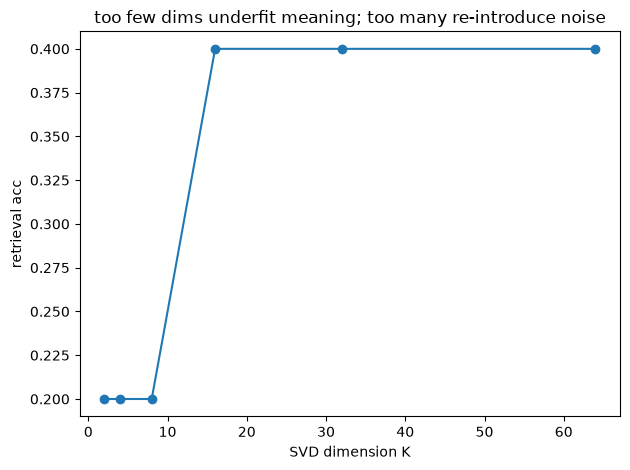

{2: 0.2, 4: 0.2, 8: 0.2, 16: 0.4, 32: 0.4, 64: 0.4}


In [13]:
# ---- Solution 2 ----
def acc_for_K(k):
    wvk = U[:, :k] * S[:k]
    def emb(s):
        vs = [wvk[idx[w]] for w in tokens(s) if w in idx]
        return np.mean(vs,0) if vs else np.zeros(k)
    Dk = np.array([emb(d) for d in DOCS]); Dk /= (np.linalg.norm(Dk,axis=1,keepdims=True)+1e-9)
    h = 0
    for q, gold in QUERIES:
        qq = emb(q); qq /= (np.linalg.norm(qq)+1e-9); h += int(np.argmax(Dk@qq)==gold)
    return h/len(QUERIES)
Ks = [2,4,8,16,32,64]
accs = [acc_for_K(k) for k in Ks]
plt.plot(Ks, accs, marker="o"); plt.xlabel("SVD dimension K"); plt.ylabel("retrieval acc")
plt.title("too few dims underfit meaning; too many re-introduce noise"); plt.tight_layout(); plt.show()
print(dict(zip(Ks, accs)))

In [14]:
# ---- Solution 5 ----
q = "how do I request reimbursement"
in_vocab = [w for w in tokens(q) if w in idx]
print("SVD sees only these query words:", in_vocab, "-> 'reimbursement' is dropped")
print("SVD top doc:", semantic_search(q)[0])
print("MiniLM top doc:", real_search(q)[0], "->", DOCS[real_search(q)[0][0]])
print("\nS5: subword tokenisation ('re', '##im', '##burse', '##ment') lets the real model place")
print("an unseen word near 'refund'. Bag-of-word-vectors can't represent OOV terms at all.")

SVD sees only these query words: ['how', 'do', 'i'] -> 'reimbursement' is dropped
SVD top doc: (0, 0.16708155865092542)
MiniLM top doc: (0, 0.4027354121208191) -> Refunds are processed within 5 business days to the original payment method.

S5: subword tokenisation ('re', '##im', '##burse', '##ment') lets the real model place
an unseen word near 'refund'. Bag-of-word-vectors can't represent OOV terms at all.


In [15]:
# ---- Solution 6 ----
# fresh queries (not stored): jitter base embeddings with independent noise
Qbig = np.repeat(base, 25, axis=0) + 0.035 * rng.standard_normal((len(DOCS)*25, base.shape[1]))
Qbig /= np.linalg.norm(Qbig, axis=1, keepdims=True)

def lsh_recall(n_planes, n_tables):
    L = LSH(big, n_planes=n_planes, n_tables=n_tables)
    hit, cand = 0, []
    for q in Qbig:
        c = L.candidates(q); cand.append(len(c))       # no full-scan fallback here
        exact = int(np.argmax(big @ q))
        hit += exact in c                              # was the true NN even a candidate?
    return hit/len(Qbig), np.mean(cand)

print(f"{'planes':>7} {'tables':>7} {'recall@1':>9} {'avg cands':>10}")
for npl, nt in [(8,1), (8,4), (8,10), (8,20), (12,20), (16,20)]:
    r, c = lsh_recall(npl, nt)
    print(f"{npl:>7} {nt:>7} {r:>9.2f} {c:>10.0f} / {len(big)}")
print("S6: more planes -> smaller buckets (faster, lower recall); more tables -> more buckets")
print("    probed -> recall back up at higher cost. That two-knob tradeoff is the core of ANN.")

 planes  tables  recall@1  avg cands


      8       1      0.09         21 / 2000
      8       4      0.34        113 / 2000


      8      10      0.77        246 / 2000


      8      20      0.92        422 / 2000
     12      20      0.55        119 / 2000


     16      20      0.23         38 / 2000
S6: more planes -> smaller buckets (faster, lower recall); more tables -> more buckets
    probed -> recall back up at higher cost. That two-knob tradeoff is the core of ANN.


### Solutions 3 & 4 (sketch)

**S3:** after `DOCS[3] = " ".join(tokens(DOCS[3]) * 10)`, rebuild an *un-normalised* doc matrix
and rank by raw `D @ q`. `DOCS[3]`'s vector norm is ~10× bigger so it floats to the top of
almost every query. Switch to cosine (normalise rows) and it drops back to its semantic rank.
This is why you normalise.

**S4:** `blended = w * minmax(bm25_scores) + (1-w) * minmax(sem_scores)`; loop `w` in
`np.linspace(0,1,11)`, count `TESTS` hits. Usually a broad plateau around `w ≈ 0.3–0.6` beats
either pure method — the exact value is dataset-specific, which is why rank-fusion (RRF, no
weight to tune) is popular.

## Self-check quiz

1. Why does bag-of-words cosine similarity fail on "money back" vs "refund"?
2. State the distributional hypothesis and how the co-occurrence + SVD pipeline uses it.
3. On L2-normalised vectors, how do cosine, dot product, and Euclidean ranking relate?
4. Why do vector databases store normalised vectors and use inner product?
5. Give two query types where BM25 beats dense retrieval.
6. What does Reciprocal Rank Fusion combine, and why is it preferred over score blending?
7. What does an ANN index trade away, and for what?

### Answer key

1. Distinct words are orthogonal one-hot dimensions, so their similarity is exactly 0 — the
   representation encodes no relationship between different words.
2. "A word's meaning is characterised by the contexts it appears in." Build a word×context
   co-occurrence matrix over a corpus; words with similar meaning have similar rows; SVD
   compresses those rows to dense vectors preserving the similarity structure.
3. They give the **same ranking**: dot = cosine (norms are 1), and `‖a-b‖² = 2 - 2(a·b)` is
   monotonically decreasing in the dot product.
4. Because then a single inner-product matmul equals cosine similarity — fastest to compute,
   no per-query norm, and the metric matches how text embeddings encode meaning (direction).
5. Exact/rare terms: product codes, proper names, error strings, code identifiers, acronyms —
   anything where the literal token matters and paraphrase doesn't.
6. It combines the **rank positions** each retriever assigns to a document
   (`Σ 1/(c + rank)`), not their raw scores — so it needs no score calibration between a BM25
   score and a cosine similarity, which live on different scales.
7. Recall (it may miss the true nearest neighbour) in exchange for sublinear query time /
   lower memory — essential past ~10⁵–10⁶ vectors.

## Where this goes next

- **Day 14 — Vector databases:** you have vectors and a search; now the storage layer. IVF vs
  HNSW indexes, the recall/latency/memory tradeoff, metadata filtering, and choosing between
  pgvector, Pinecone, and Weaviate.